# CIFAR-10 SNGP Embeddings UMAP

Load the SNGP checkpoint trained by `experiments/cifar10_sngp.py`, extract CIFAR-10 train and test backbone embeddings, project both splits with UMAP, and save split-specific arrays with a checkpoint-identifiable filename.


In [11]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

try:
    import umap
except ImportError as exc:
    raise ImportError("Install UMAP with `pip install umap-learn` before running this notebook.") from exc

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / "src").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError(f"Could not find repo root from {cwd}")

sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from src.data.cifar10 import get_cifar10_loaders
from src.models.sngp import SNGPResNetClassifier, laplace_predictive_probs

print("repo root:", REPO_ROOT)


repo root: /w/20252/wjcai/uq/manygp


In [12]:
CHECKPOINT_PATH = Path("/w/20251/wjcai/checkpoints_sngp/20260421_210700_0bb4464f/cifar10_sngp_epoch175_acc0.9323.pt")
FALLBACK_CONFIG_PATH = REPO_ROOT / "configs" / "cifar10_sngp.yaml"

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

cfg = checkpoint.get("config")
if cfg is None:
    with open(FALLBACK_CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)

print("device:", device)
print("checkpoint:", CHECKPOINT_PATH)
print("checkpoint epoch:", checkpoint.get("epoch"))
print("stored val accuracy:", checkpoint.get("val_accuracy"))
print("stored val nll:", checkpoint.get("val_nll"))


device: cuda
checkpoint: /w/20251/wjcai/checkpoints_sngp/20260421_210700_0bb4464f/cifar10_sngp_epoch175_acc0.9323.pt
checkpoint epoch: 175
stored val accuracy: 0.9323
stored val nll: 0.3246524028778076


In [13]:
model_cfg = cfg["model"]
model = SNGPResNetClassifier(
    num_classes=model_cfg["num_classes"],
    width=model_cfg["width"],
    hidden_dim=model_cfg["hidden_dim"],
    spec_norm_bound=model_cfg["spec_norm_bound"],
    num_inducing=model_cfg["num_inducing"],
    ridge_penalty=model_cfg["ridge_penalty"],
    feature_scale=model_cfg["feature_scale"],
    gp_cov_momentum=model_cfg["gp_cov_momentum"],
    normalize_input=model_cfg["normalize_input"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(model)


SNGPResNetClassifier(
  (backbone): SNGPResNetBackbone(
    (stem): Sequential(
      (0): SpectralConv2d(
        (conv): ParametrizedConv2d(
          3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _SpectralNorm()
            )
          )
        )
      )
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (layer1): Sequential(
      (0): SNGPResidualBlock(
        (conv1): SpectralConv2d(
          (conv): ParametrizedConv2d(
            64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
            (parametrizations): ModuleDict(
              (weight): ParametrizationList(
                (0): _SpectralNorm()
              )
            )
          )
        )
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [14]:
data_cfg = cfg["data"]
batch_size = data_cfg.get("batch_size", 256)

train_loader, test_loader, train_dataset, test_dataset = get_cifar10_loaders(
    data_root=data_cfg["root"],
    batch_size=batch_size,
    num_workers=0,
    smoke_test=False,
)

CIFAR10_CLASSES = test_dataset.classes
print("train size:", len(train_dataset))
print("test size:", len(test_dataset))
print("classes:", CIFAR10_CLASSES)


/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train size: 50000
test size: 10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [15]:
@torch.no_grad()
def collect_embeddings(model, loader, device, num_mc_samples=10):
    model.eval()
    embeddings = []
    labels = []
    logits = []
    probs = []
    preds = []
    variances = []

    for images, batch_labels in loader:
        images = images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        batch_embeddings = model.encode(images)
        batch_logits, batch_variances = model(images, return_cov=True)
        batch_probs = laplace_predictive_probs(
            batch_logits,
            batch_variances,
            num_mc_samples=num_mc_samples,
        )

        embeddings.append(batch_embeddings.cpu())
        labels.append(batch_labels.cpu())
        logits.append(batch_logits.cpu())
        variances.append(batch_variances.cpu())
        probs.append(batch_probs.cpu())
        preds.append(batch_probs.argmax(dim=1).cpu())

    return {
        "embeddings": torch.cat(embeddings, dim=0),
        "labels": torch.cat(labels, dim=0),
        "logits": torch.cat(logits, dim=0),
        "variances": torch.cat(variances, dim=0),
        "probs": torch.cat(probs, dim=0),
        "preds": torch.cat(preds, dim=0),
    }


num_mc_samples = cfg.get("training", {}).get("num_mc_samples", 10)
train_outputs = collect_embeddings(
    model=model,
    loader=train_loader,
    device=device,
    num_mc_samples=num_mc_samples,
)
test_outputs = collect_embeddings(
    model=model,
    loader=test_loader,
    device=device,
    num_mc_samples=num_mc_samples,
)

train_embeddings = train_outputs["embeddings"]
train_labels = train_outputs["labels"]
train_probs = train_outputs["probs"]
train_preds = train_outputs["preds"]
train_variances = train_outputs["variances"]

test_embeddings = test_outputs["embeddings"]
test_labels = test_outputs["labels"]
test_probs = test_outputs["probs"]
test_preds = test_outputs["preds"]
test_variances = test_outputs["variances"]

print("train embeddings:", tuple(train_embeddings.shape))
print("train labels:", tuple(train_labels.shape))
print("test embeddings:", tuple(test_embeddings.shape))
print("test labels:", tuple(test_labels.shape))


train embeddings: (50000, 128)
train labels: (50000,)
test embeddings: (10000, 128)
test labels: (10000,)


In [16]:
test_correct = test_preds.eq(test_labels)
test_nll = -test_probs.clamp_min(1e-12).log().gather(1, test_labels.unsqueeze(1)).mean().item()
test_accuracy = test_correct.float().mean().item()
test_entropy = -(test_probs.clamp_min(1e-12) * test_probs.clamp_min(1e-12).log()).sum(dim=1)
test_gp_variance = test_variances.mean(dim=1)

train_correct = train_preds.eq(train_labels)
train_accuracy = train_correct.float().mean().item()
train_entropy = -(train_probs.clamp_min(1e-12) * train_probs.clamp_min(1e-12).log()).sum(dim=1)
train_gp_variance = train_variances.mean(dim=1)

print(f"train accuracy: {train_accuracy * 100:.2f}%")
print(f"test accuracy: {test_accuracy * 100:.2f}%")
print(f"test NLL: {test_nll:.4f}")
print(f"mean test predictive entropy: {test_entropy.mean().item():.4f}")
print(f"mean test GP variance: {test_gp_variance.mean().item():.4f}")


train accuracy: 98.45%
test accuracy: 93.11%
test NLL: 0.3230
mean test predictive entropy: 0.0630
mean test GP variance: 0.7680


In [17]:
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

train_embedding_2d = umap_model.fit_transform(train_embeddings.numpy())
test_embedding_2d = umap_model.transform(test_embeddings.numpy())
print("train UMAP projection:", train_embedding_2d.shape)
print("test UMAP projection:", test_embedding_2d.shape)


/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


train UMAP projection: (50000, 2)
test UMAP projection: (10000, 2)


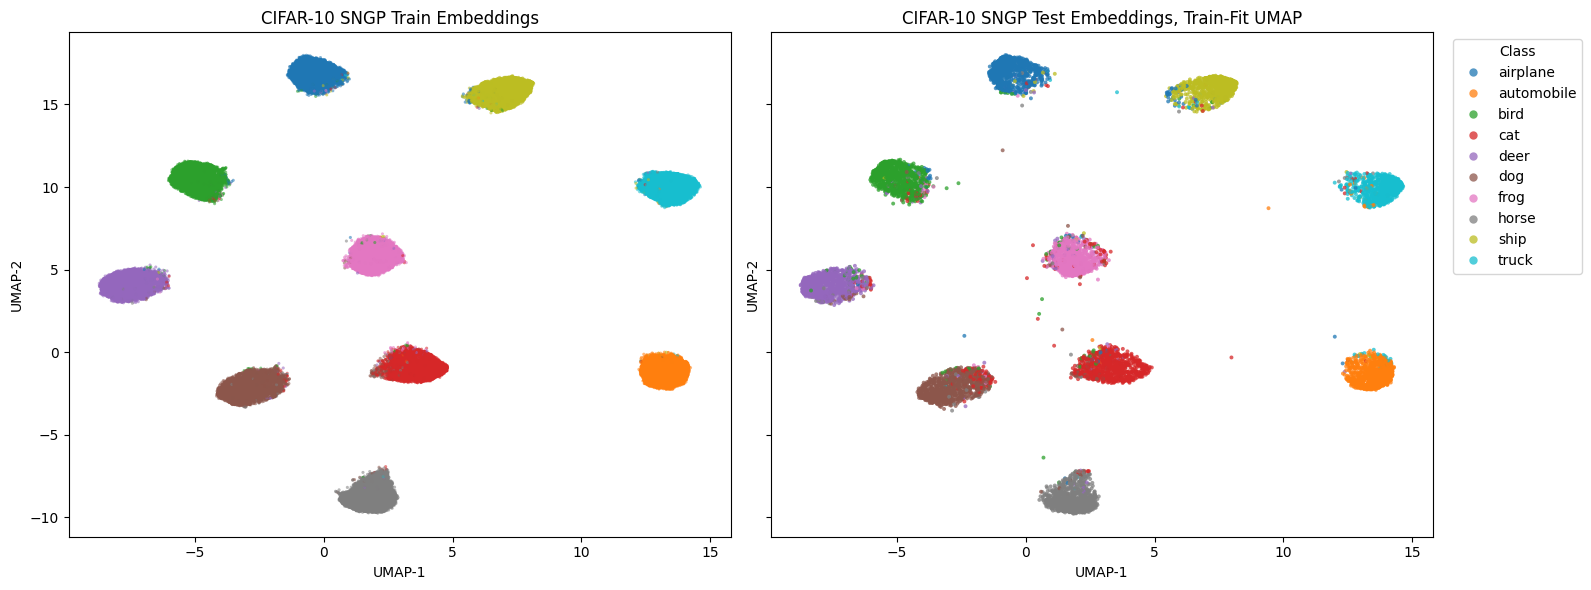

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

train_scatter = axes[0].scatter(
    train_embedding_2d[:, 0],
    train_embedding_2d[:, 1],
    c=train_labels.numpy(),
    cmap="tab10",
    s=5,
    alpha=0.55,
    linewidths=0,
)
axes[0].set_title("CIFAR-10 SNGP Train Embeddings")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

test_scatter = axes[1].scatter(
    test_embedding_2d[:, 0],
    test_embedding_2d[:, 1],
    c=test_labels.numpy(),
    cmap="tab10",
    s=8,
    alpha=0.75,
    linewidths=0,
)
axes[1].set_title("CIFAR-10 SNGP Test Embeddings, Train-Fit UMAP")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

handles, _ = test_scatter.legend_elements(num=len(CIFAR10_CLASSES))
axes[1].legend(handles, CIFAR10_CLASSES, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


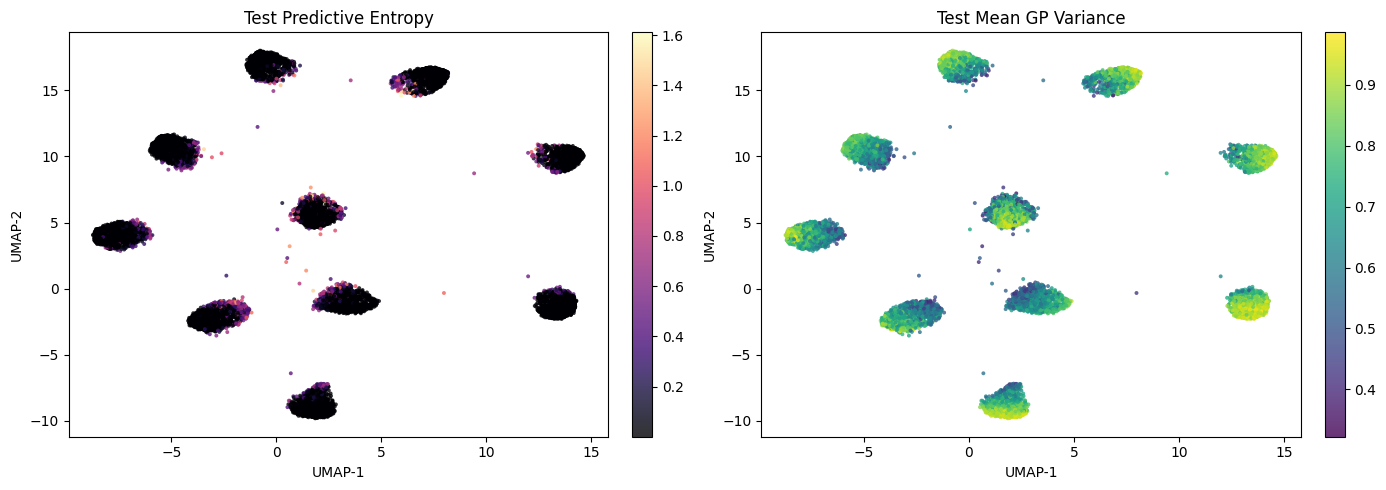

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

entropy_plot = axes[0].scatter(
    test_embedding_2d[:, 0],
    test_embedding_2d[:, 1],
    c=test_entropy.numpy(),
    cmap="magma",
    s=8,
    alpha=0.8,
    linewidths=0,
)
axes[0].set_title("Test Predictive Entropy")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
plt.colorbar(entropy_plot, ax=axes[0], fraction=0.046, pad=0.04)

variance_plot = axes[1].scatter(
    test_embedding_2d[:, 0],
    test_embedding_2d[:, 1],
    c=test_gp_variance.numpy(),
    cmap="viridis",
    s=8,
    alpha=0.8,
    linewidths=0,
)
axes[1].set_title("Test Mean GP Variance")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
plt.colorbar(variance_plot, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
checkpoint_id = CHECKPOINT_PATH.stem
output_path = REPO_ROOT / "notebooks" / "gmm" / f"sngp_embeddings_{checkpoint_id}.npz"
np.savez_compressed(
    output_path,
    train_embeddings=train_embeddings.numpy(),
    train_labels=train_labels.numpy(),
    train_preds=train_preds.numpy(),
    train_probs=train_probs.numpy(),
    train_variances=train_variances.numpy(),
    train_entropy=train_entropy.numpy(),
    train_gp_variance=train_gp_variance.numpy(),
    train_umap=train_embedding_2d,
    test_embeddings=test_embeddings.numpy(),
    test_labels=test_labels.numpy(),
    test_preds=test_preds.numpy(),
    test_probs=test_probs.numpy(),
    test_variances=test_variances.numpy(),
    test_entropy=test_entropy.numpy(),
    test_gp_variance=test_gp_variance.numpy(),
    test_umap=test_embedding_2d,
    classes=np.array(CIFAR10_CLASSES),
    checkpoint_id=checkpoint_id,
    checkpoint_path=str(CHECKPOINT_PATH),
    checkpoint_epoch=checkpoint.get("epoch", -1),
    checkpoint_val_accuracy=checkpoint.get("val_accuracy", np.nan),
)
print("checkpoint id:", checkpoint_id)
print("saved:", output_path)
